# R-values of ideal texture components

For this notebook, the <ins>DAMASK available at the package manager</ins> is used. 

In this notebook, we are documenting the R-value of ideal components that we get from DAMASK.

Along with the R-value documentation, we also document the method of calculation.

The R-values are compared to the values that you get from VPSC simulation and compared to values seen in literature.

Following ideal orientations are considered
1. Cube
2. Cube-45 (Rotated along ND)
3. S
4. Copper
5. Brass
6. Goss

## Creating files for ideal orientations

In [1]:
from damask import Rotation
from damask import ConfigMaterial as cm
import numpy as np
from pathlib import Path
import os

In [2]:
ideal_ori_dict = {'Cube'   : np.array([0.0,0.0,0.0]),\
                  'Cube_45': np.array([45.0,0.0,0.0]),\
                  'S'      : np.array([58.9799,143.301,206.565]),\
                  'Copper' : np.array([90.0,35.0,45.0]),\
                  'Brass'  : np.array([35.0,45.0,0.0]),\
                  'Goss'   : np.array([0.0,45.0,0.0])}

### Material file with rotated orientations

In the code block below, the ideal orientations are generated and then depending on the test direction, they are correspondingly rotated. 

This is done, so that the tensile test itself happens in the same direction always. 

It is considered that rotating the orientations is same as rotating the tensile test direction. 

In [3]:
notebook_root_dir = os.getcwd()

In [4]:
for key,i in ideal_ori_dict.items():
    for ang in [0,45,90]:
        Path(notebook_root_dir + f'/{key}/simulation_{ang}/postProc').mkdir(parents=True, exist_ok=True)

        # creating the ideal orientations
        ori = Rotation.from_spherical_component(center=Rotation.from_Euler_angles(i,degrees=True),sigma=0.0,shape=8,degrees=True)

        # rotation quaternion
        rot_quat = Rotation.from_axis_angle(np.array([0.0,0.0,1.0,float(ang)]),degrees=True)
        rot_quat = rot_quat.broadcast_to(len(ori))

        # rotated the ideal orientation
        rotated_quats = rot_quat*ori

        config = cm().material_add(O=rotated_quats,phase='Aluminum',homogenization='SX')
        mat_default = cm.load('material_default.yaml')
        config['phase'] = mat_default['phase']
        config['homogenization'] = mat_default['homogenization']

        config.save(notebook_root_dir + f'/{key}/simulation_{ang}/material.yaml')

### Copying geom and load files to the folders

In [5]:
from shutil import copy

In [6]:
for key,i in ideal_ori_dict.items():
    for ang in [0,45,90]:
        copy('3D_orientations_8.vti',notebook_root_dir + f'/{key}/simulation_{ang}/3D_orientations_8.vti')
        copy('tensionX.yaml',notebook_root_dir + f'/{key}/simulation_{ang}/tensionX.yaml')

## Run the simulations

In [8]:
import damask

In [9]:
for key,i in ideal_ori_dict.items():
    for ang in [0,45,90]:
        os.chdir(notebook_root_dir + f'/{key}/simulation_{ang}/')
        damask.util.run('DAMASK_grid -l tensionX.yaml -g 3D_orientations_8.vti -m material.yaml')

2026-09-01 12:54:15,981 - INFO - running 'DAMASK_grid -l tensionX.yaml -g 3D_orientations_8.vti -m material.yaml' in './'
2026-09-01 12:54:21,288 - INFO - running 'DAMASK_grid -l tensionX.yaml -g 3D_orientations_8.vti -m material.yaml' in './'
2026-09-01 12:54:26,924 - INFO - running 'DAMASK_grid -l tensionX.yaml -g 3D_orientations_8.vti -m material.yaml' in './'
2026-09-01 12:54:32,258 - INFO - running 'DAMASK_grid -l tensionX.yaml -g 3D_orientations_8.vti -m material.yaml' in './'
2026-09-01 12:54:37,756 - INFO - running 'DAMASK_grid -l tensionX.yaml -g 3D_orientations_8.vti -m material.yaml' in './'
2026-09-01 12:54:43,259 - INFO - running 'DAMASK_grid -l tensionX.yaml -g 3D_orientations_8.vti -m material.yaml' in './'
2026-09-01 12:54:48,867 - INFO - running 'DAMASK_grid -l tensionX.yaml -g 3D_orientations_8.vti -m material.yaml' in './'
2026-09-01 12:54:54,524 - INFO - running 'DAMASK_grid -l tensionX.yaml -g 3D_orientations_8.vti -m material.yaml' in './'
2026-09-01 12:55:00,239 

## Post Processing the data

Adding necessary data for r-value calculation

In [10]:
for key,i in ideal_ori_dict.items():
    for ang in [0,45,90]:
        os.chdir(notebook_root_dir + f'/{key}/simulation_{ang}/')
        d = damask.Result('3D_orientations_8_tensionX_material.hdf5')
        d.add_strain('F_p','U')
        d.add_equivalent_Mises('epsilon_U^0.0(F_p)')

Accumulating data together

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

Plot all components together

/tmp/ipykernel_48286/3656301291.py:10: RuntimeWarning: invalid value encountered in divide
  r = epsilon_avg[:,1,1]/epsilon_avg[:,2,2]
/tmp/ipykernel_48286/3656301291.py:10: RuntimeWarning: invalid value encountered in divide
  r = epsilon_avg[:,1,1]/epsilon_avg[:,2,2]
/tmp/ipykernel_48286/3656301291.py:10: RuntimeWarning: invalid value encountered in divide
  r = epsilon_avg[:,1,1]/epsilon_avg[:,2,2]
/tmp/ipykernel_48286/3656301291.py:10: RuntimeWarning: invalid value encountered in divide
  r = epsilon_avg[:,1,1]/epsilon_avg[:,2,2]
/tmp/ipykernel_48286/3656301291.py:10: RuntimeWarning: invalid value encountered in divide
  r = epsilon_avg[:,1,1]/epsilon_avg[:,2,2]
/tmp/ipykernel_48286/3656301291.py:10: RuntimeWarning: divide by zero encountered in divide
  r = epsilon_avg[:,1,1]/epsilon_avg[:,2,2]
/tmp/ipykernel_48286/3656301291.py:10: RuntimeWarning: invalid value encountered in divide
  r = epsilon_avg[:,1,1]/epsilon_avg[:,2,2]
/tmp/ipykernel_48286/3656301291.py:10: RuntimeWarning:

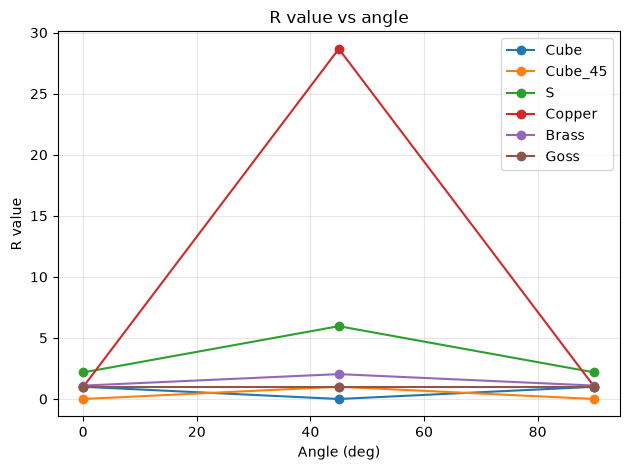

In [25]:
fig = plt.figure()
for key,i in ideal_ori_dict.items():
    avg_r_rows = []
    for ang in [0,45,90]:
        os.chdir(notebook_root_dir + f'/{key}/simulation_{ang}/')
        d = damask.Result('3D_orientations_8_tensionX_material.hdf5')
        epsilon_avg = np.array([np.average(eps,0) for eps in d.get('epsilon_U^0.0(F_p)').values()])
        r = epsilon_avg[:,1,1]/epsilon_avg[:,2,2]
        s = np.array([np.average(strain) for strain in d.get('epsilon_U^0.0(F_p)_vM').values()])
        df = pd.DataFrame({'R_value': r, 'Strain': s})

        # Filter the DataFrame to include only the strain values within the desired range
        df_window = df.loc[(df['Strain'] >= 0.02) & (df['Strain'] <= 0.1)]
        # Average R_value over that subset
        avg_r_value = df_window['R_value'].mean()

        df.to_csv(notebook_root_dir + f'/{key}/simulation_{ang}/postProc/R_value_vs_strain_{int(ang)}.csv', index=False)

        avg_r_rows.append({'Angle': float(ang), 'Average_R_value': avg_r_value})

    # plot
    df_plot = pd.DataFrame(avg_r_rows).sort_values('Angle')
    plt.plot(df_plot['Angle'], df_plot['Average_R_value'], marker='o', linestyle='-',label=f'{key}')
    plt.xlabel('Angle (deg)')
    plt.ylabel('R value')
    plt.title('R value vs angle')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.legend()

Plot individual components

/tmp/ipykernel_48286/598461922.py:9: RuntimeWarning: invalid value encountered in divide
  r = epsilon_avg[:,1,1]/epsilon_avg[:,2,2]
/tmp/ipykernel_48286/598461922.py:9: RuntimeWarning: invalid value encountered in divide
  r = epsilon_avg[:,1,1]/epsilon_avg[:,2,2]
/tmp/ipykernel_48286/598461922.py:9: RuntimeWarning: invalid value encountered in divide
  r = epsilon_avg[:,1,1]/epsilon_avg[:,2,2]
/tmp/ipykernel_48286/598461922.py:9: RuntimeWarning: invalid value encountered in divide
  r = epsilon_avg[:,1,1]/epsilon_avg[:,2,2]
/tmp/ipykernel_48286/598461922.py:9: RuntimeWarning: invalid value encountered in divide
  r = epsilon_avg[:,1,1]/epsilon_avg[:,2,2]
/tmp/ipykernel_48286/598461922.py:9: RuntimeWarning: divide by zero encountered in divide
  r = epsilon_avg[:,1,1]/epsilon_avg[:,2,2]
/tmp/ipykernel_48286/598461922.py:9: RuntimeWarning: invalid value encountered in divide
  r = epsilon_avg[:,1,1]/epsilon_avg[:,2,2]
/tmp/ipykernel_48286/598461922.py:9: RuntimeWarning: invalid value e

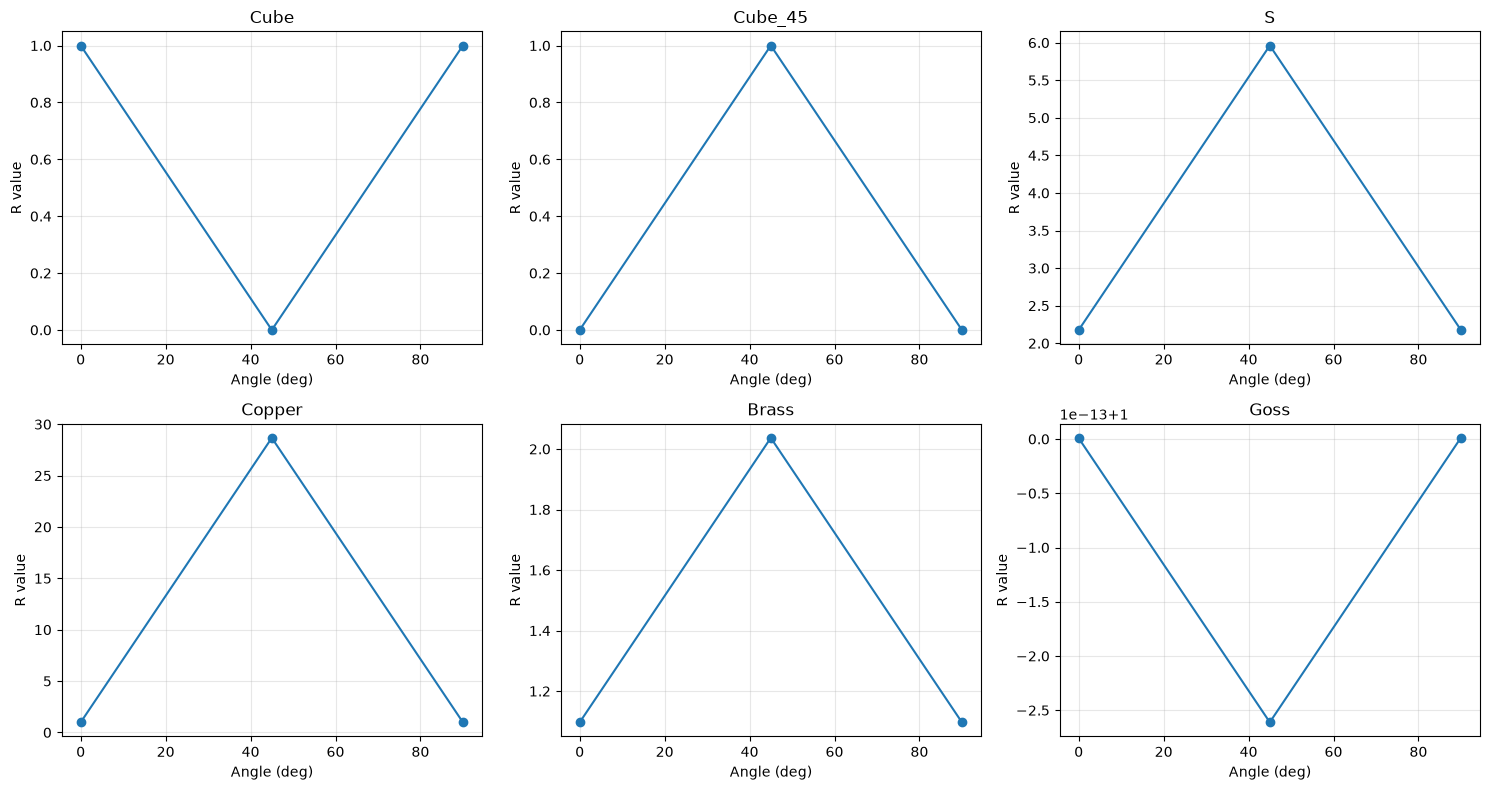

In [34]:
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
ax_flat = ax.flatten()
for count, key in enumerate(ideal_ori_dict.keys()):
    avg_r_rows = []
    for ang in [0,45,90]:
        os.chdir(notebook_root_dir + f'/{key}/simulation_{ang}/')
        d = damask.Result('3D_orientations_8_tensionX_material.hdf5')
        epsilon_avg = np.array([np.average(eps,0) for eps in d.get('epsilon_U^0.0(F_p)').values()])
        r = epsilon_avg[:,1,1]/epsilon_avg[:,2,2]
        s = np.array([np.average(strain) for strain in d.get('epsilon_U^0.0(F_p)_vM').values()])
        df = pd.DataFrame({'R_value': r, 'Strain': s})

        # Filter the DataFrame to include only the strain values within the desired range
        df_window = df.loc[(df['Strain'] >= 0.02) & (df['Strain'] <= 0.1)]
        # Average R_value over that subset
        avg_r_value = df_window['R_value'].mean()

        df.to_csv(notebook_root_dir + f'/{key}/simulation_{ang}/postProc/R_value_vs_strain_{int(ang)}.csv', index=False)

        avg_r_rows.append({'Angle': float(ang), 'Average_R_value': avg_r_value})

    # plot
    df_plot = pd.DataFrame(avg_r_rows).sort_values('Angle')
    axis = ax_flat[count]
    axis.plot(df_plot['Angle'], df_plot['Average_R_value'], marker='o', linestyle='-', label=f'{key}')
    axis.set_xlabel('Angle (deg)')
    axis.set_ylabel('R value')
    axis.set_title(f'{key}')
    axis.grid(True, alpha=0.3)

fig.tight_layout()


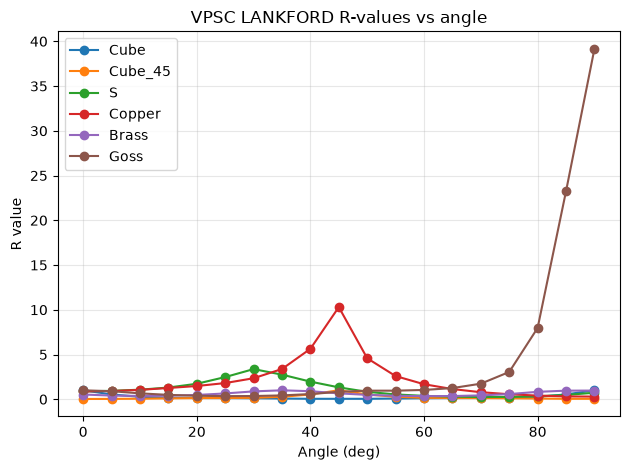

In [35]:
fig, ax = plt.subplots()
for key in ideal_ori_dict.keys():
    lankford_file = notebook_root_dir + f'/LANKFORD_{key}.OUT'
    df_lankford = pd.read_csv(lankford_file, sep=r'\s+')
    ax.plot(df_lankford['ANGLE'], df_lankford['LANKF'], marker='o', linestyle='-', label=key)

ax.set_xlabel('Angle (deg)')
ax.set_ylabel('R value')
ax.set_title('VPSC LANKFORD R-values vs angle')
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()


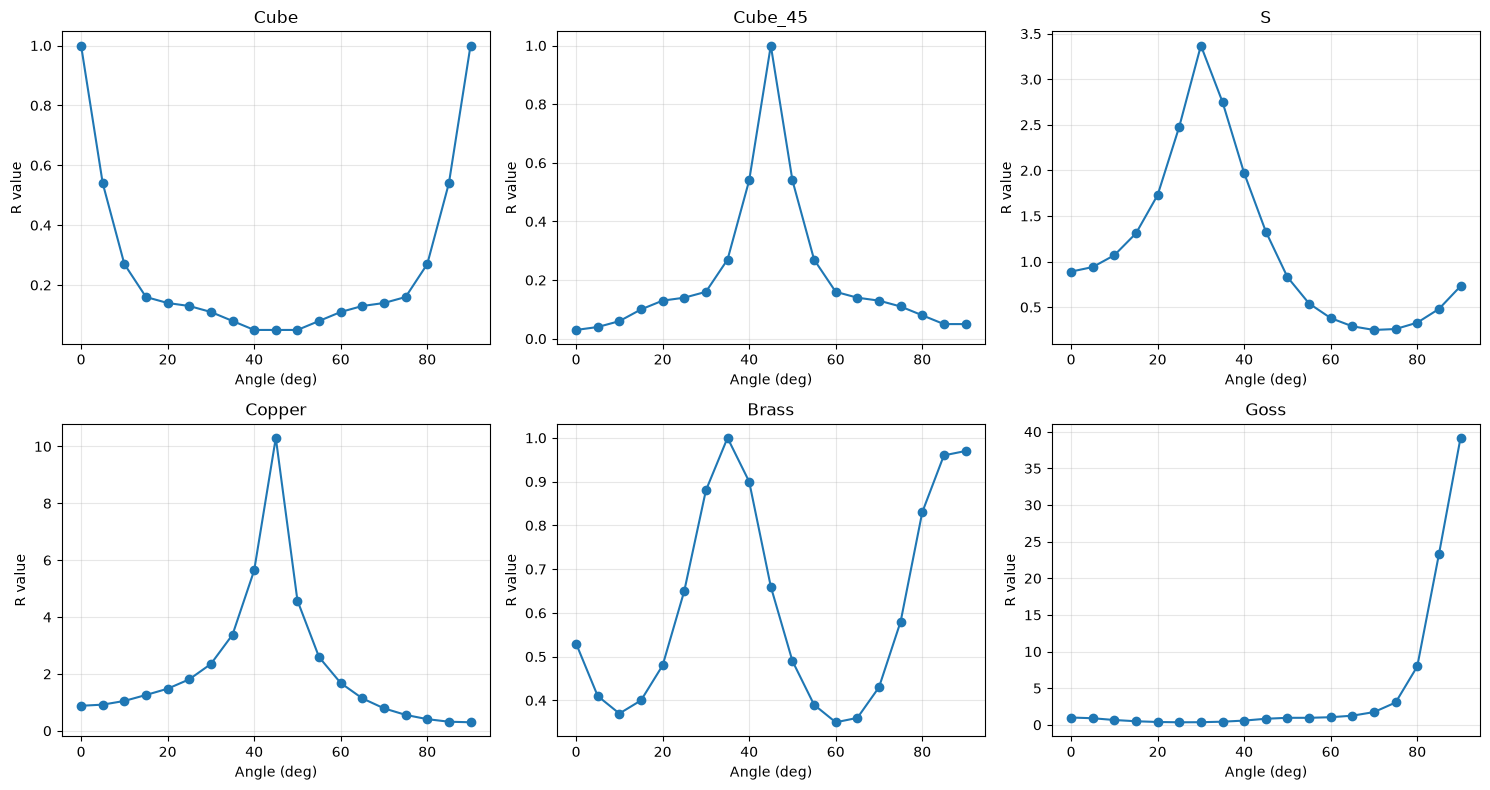

In [36]:
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
ax_flat = ax.flatten()
for count, key in enumerate(ideal_ori_dict.keys()):
    lankford_file = notebook_root_dir + f'/LANKFORD_{key}.OUT'
    df_lankford = pd.read_csv(lankford_file, sep=r'\s+')

    axis = ax_flat[count]
    axis.plot(df_lankford['ANGLE'], df_lankford['LANKF'], marker='o', linestyle='-', label=key)
    axis.set_xlabel('Angle (deg)')
    axis.set_ylabel('R value')
    axis.set_title(f'{key}')
    axis.grid(True, alpha=0.3)

fig.tight_layout()


Out of all the orientations, (if we only compare the 0, 45, 90 degree values) then only Cube, Cube45 match well with VPSC results. 


The Copper and S components have similar trends (comparing only 0, 45, 90 values).

However, Brass and Goss components are quite a lot different. The assymmetry between 0 and 90 degrees is not being captured by DAMASK. 

The VPSC results correspond to the results cited in literature (except the Brass component):


![alt text](R_values_ideal_components.png)